# Demonstration and Evaluation of `proportionality_test_LZ`

This notebook demonstrates the usage and evaluates the properties of the covariance hypothesis testing method `proportionality_test_LZ` from `covtest.methods.hypothesis_proportionality`.

## Hypothesis Tested
We test the null hypothesis:
$$H_0: \Sigma_1 = c \Sigma_2$$
against the alternative hypothesis:
$$H_1: \Sigma_1 \neq c \Sigma_2$$
where $\Sigma_1$ and $\Sigma_2$ are the population covariance matrices of the two groups, and $c > 0$ is a scalar constant.

## Method Description
Liu & Zhou's (2014) test based on the $L_2$ distance between adjusted covariance matrices. Under the null, $\Sigma_1 = c \Sigma_2$. The test computes trace-based U-statistic estimators of $\text{tr}((\Sigma_1 - c \Sigma_2)^2)$ and standardizes the statistic to have a standard normal limiting distribution under the null. Requires $p < n_2 = N_2 - 1$.

## Notebook Contents
1. **Setup and Imports**
2. **Basic Usage**
3. **P-value Calibration Under the Null**: Checking uniformity of p-values under different distributions (Gaussian, Student-t, Laplace).
4. **Power Analysis Under Alternatives**: Power curves across different sample sizes ($n$), dimensions ($p$), and alternative covariance types (spiked, Toeplitz).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure project root is in the path
sys.path.insert(0, os.path.abspath('../..'))

from covtest.methods.hypothesis_proportionality import proportionality_test_LZ
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance
)
from covtest.diagnostics.evaluate_pvalues import analyze_pvalues
from covtest.plotting.null import plot_pvalue_diagnostics_grid
from covtest.plotting.alternative import plot_power_curve, plot_power_heatmap

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
rng = np.random.default_rng(42)


## 2. Basic Usage

Let's run a single test on synthetic data generated under the null hypothesis ($H_0: \Sigma_1 = 2.0 \cdot \Sigma_2$).


In [2]:
n, p = 100, 15
Sigma1 = np.eye(p)
Sigma2 = 2.0 * np.eye(p)

# Generate data under the null
X = generate_heavy_tailed_samples(Sigma1, n, dist_type="normal", rng=rng)
Y = generate_heavy_tailed_samples(Sigma2, n, dist_type="normal", rng=rng)

# Run the test
result = proportionality_test_LZ(X, Y)
print("Test Results:")
for k, v in result.items():
    print(f"  {k}: {v}")


Test Results:
  stat: 1.010393477532815
  p_value: 0.15615340577592773


## 3. P-value Calibration Under the Null

Under the null hypothesis, the p-values computed by the test should theoretically be uniformly distributed over $[0, 1]$. We will evaluate this calibration by running $M = 300$ simulations under three different scenarios:
- **Scenario A**: Multivariate Normal distribution.
- **Scenario B**: Multivariate Student-t distribution (df=3).
- **Scenario C**: Multivariate Laplace distribution.


In [3]:
M = 300
n, p = 100, 15
Sigma1 = np.eye(p)
Sigma2 = 2.0 * np.eye(p)

scenarios = {
    "Normal": ("normal", {}),
    "Student-t (df=3)": ("t", {"df": 3}),
    "Laplace": ("laplace", {})
}

pvals_dict = {}

print("Running null simulations...")
for name, (dist, opts) in scenarios.items():
    pvals = []
    for _ in range(M):
        X = generate_heavy_tailed_samples(Sigma1, n, dist_type=dist, options=opts, rng=rng)
        Y = generate_heavy_tailed_samples(Sigma2, n, dist_type=dist, options=opts, rng=rng)
        res = proportionality_test_LZ(X, Y)
        pvals.append(res["p_value"])
    pvals_dict[name] = np.array(pvals)
    print(f"  Completed {name}")


Running null simulations...
  Completed Normal
  Completed Student-t (df=3)
  Completed Laplace


### Diagnostic Analysis of Null P-values

We use the package's `analyze_pvalues` diagnostic utility to check the uniformity of p-values for each scenario. A well-calibrated test under $H_0$ will exhibit:
- A Kolmogorov-Smirnov p-value > 0.05 (fail to reject uniformity).
- A genomic inflation factor $\lambda_{{GC}} \approx 1$.
- Storey's $\pi_0 \approx 1$.


In [4]:
for name, pvals in pvals_dict.items():
    diagnostics = analyze_pvalues(pvals)
    print(f"=== {name} Scenario Diagnostics ===")
    print(f"  KS Test p-value: {diagnostics['ks']['pval']:.4f}")
    print(f"  Anderson-Darling stat: {diagnostics['ad']['stat']:.4f}")
    print(f"  Genomic Inflation Factor (lambda): {diagnostics['inflation_factor']:.4f}")
    print(f"  Storey's pi0: {diagnostics['storey_pi0']:.4f}")
    print()


=== Normal Scenario Diagnostics ===
  KS Test p-value: 0.1602
  Anderson-Darling stat: 286.8836
  Genomic Inflation Factor (lambda): 0.8630
  Storey's pi0: 1.0000

=== Student-t (df=3) Scenario Diagnostics ===
  KS Test p-value: 0.0000
  Anderson-Darling stat: inf
  Genomic Inflation Factor (lambda): 0.0157
  Storey's pi0: 1.0000

=== Laplace Scenario Diagnostics ===
  KS Test p-value: 0.0000
  Anderson-Darling stat: 399.7065
  Genomic Inflation Factor (lambda): 0.7582
  Storey's pi0: 1.0000



/Users/austin/Forks/scikit-covtest/covtest/diagnostics/evaluate_pvalues.py:168: RuntimeWarning: divide by zero encountered in log
  term1 = (2 * i - 1) * np.log(sorted_p)
/Users/austin/Forks/scikit-covtest/covtest/diagnostics/evaluate_pvalues.py:169: RuntimeWarning: divide by zero encountered in log
  term2 = (2 * (len(pvals) - i) + 1) * np.log(1 - sorted_p[::-1])


### Visualizing P-value Calibration
Let's plot the ECDF, histogram, and QQ-plot for each scenario to visually assess the uniformity of the null p-values.


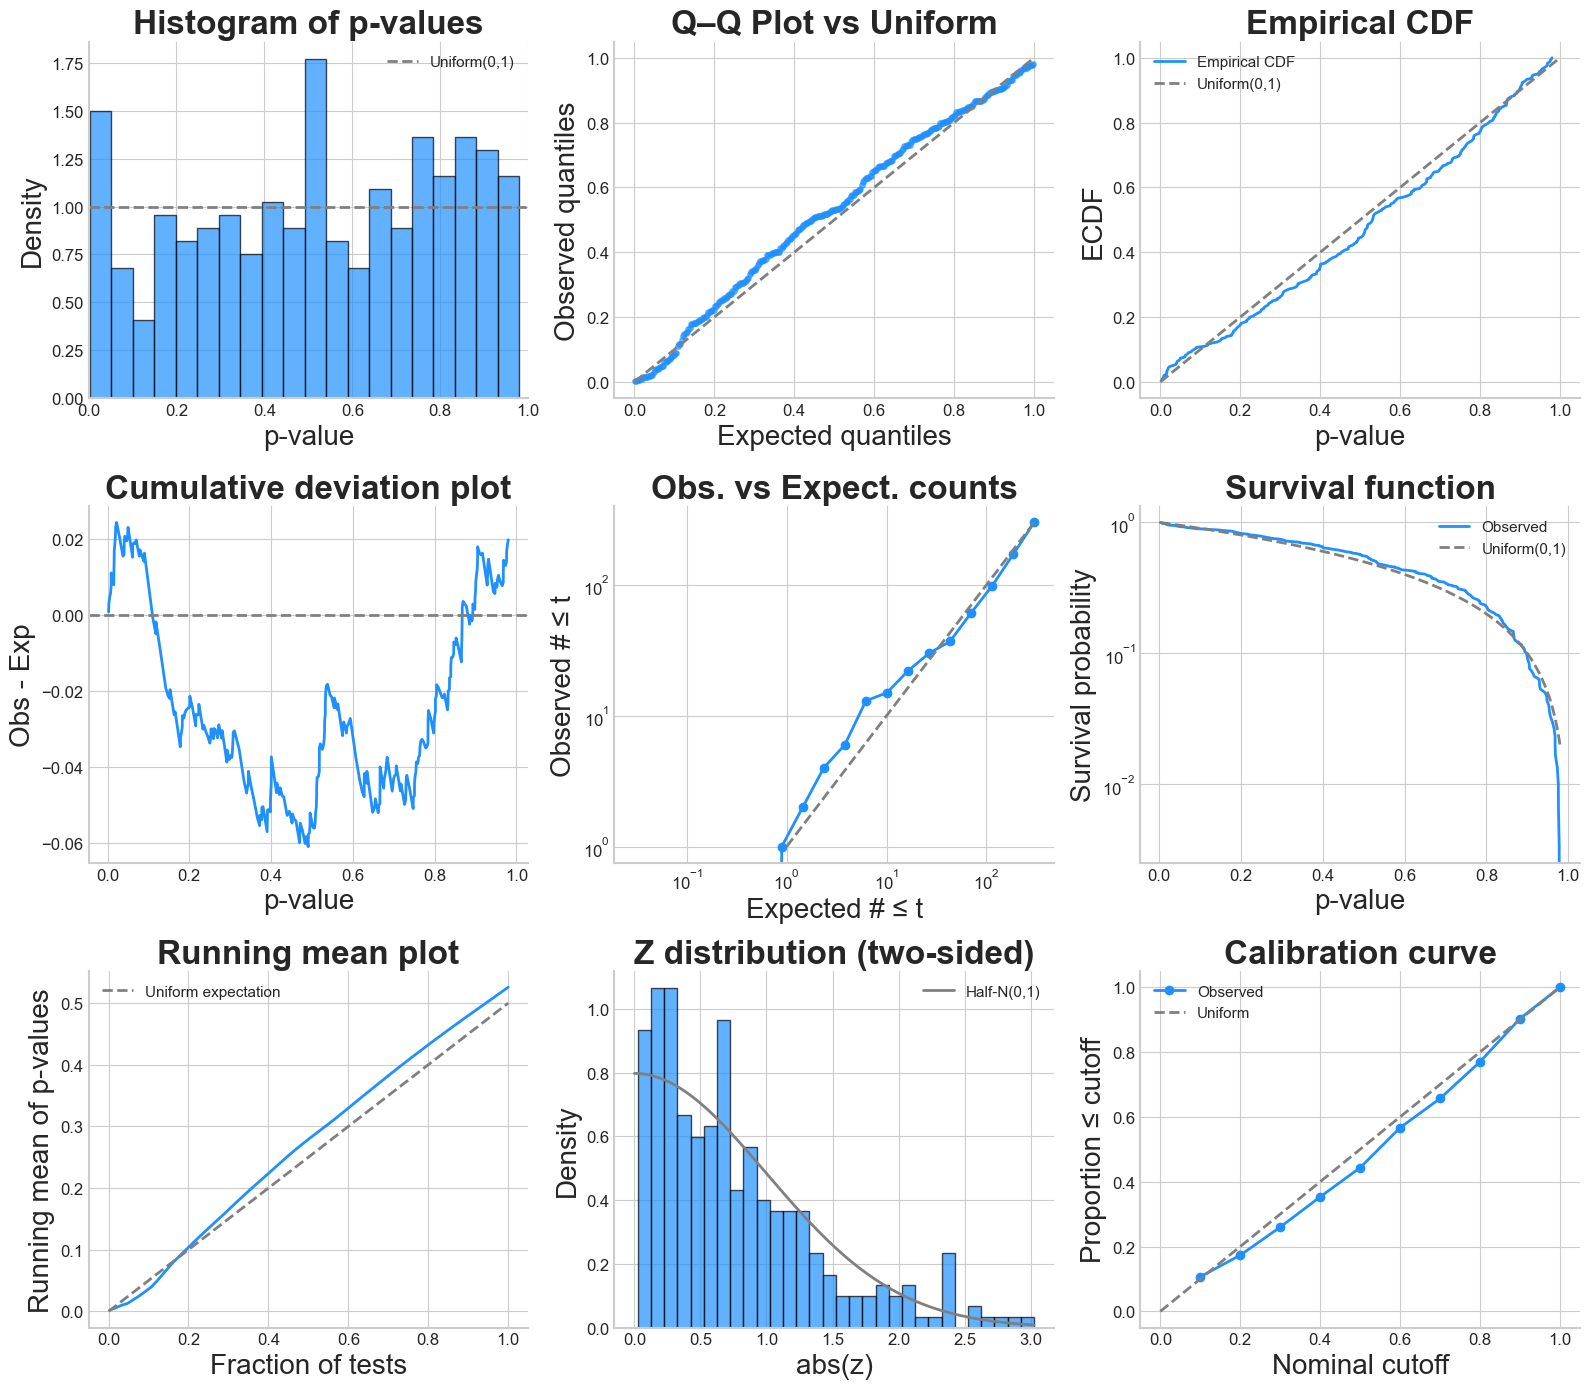

<Figure size 640x480 with 0 Axes>

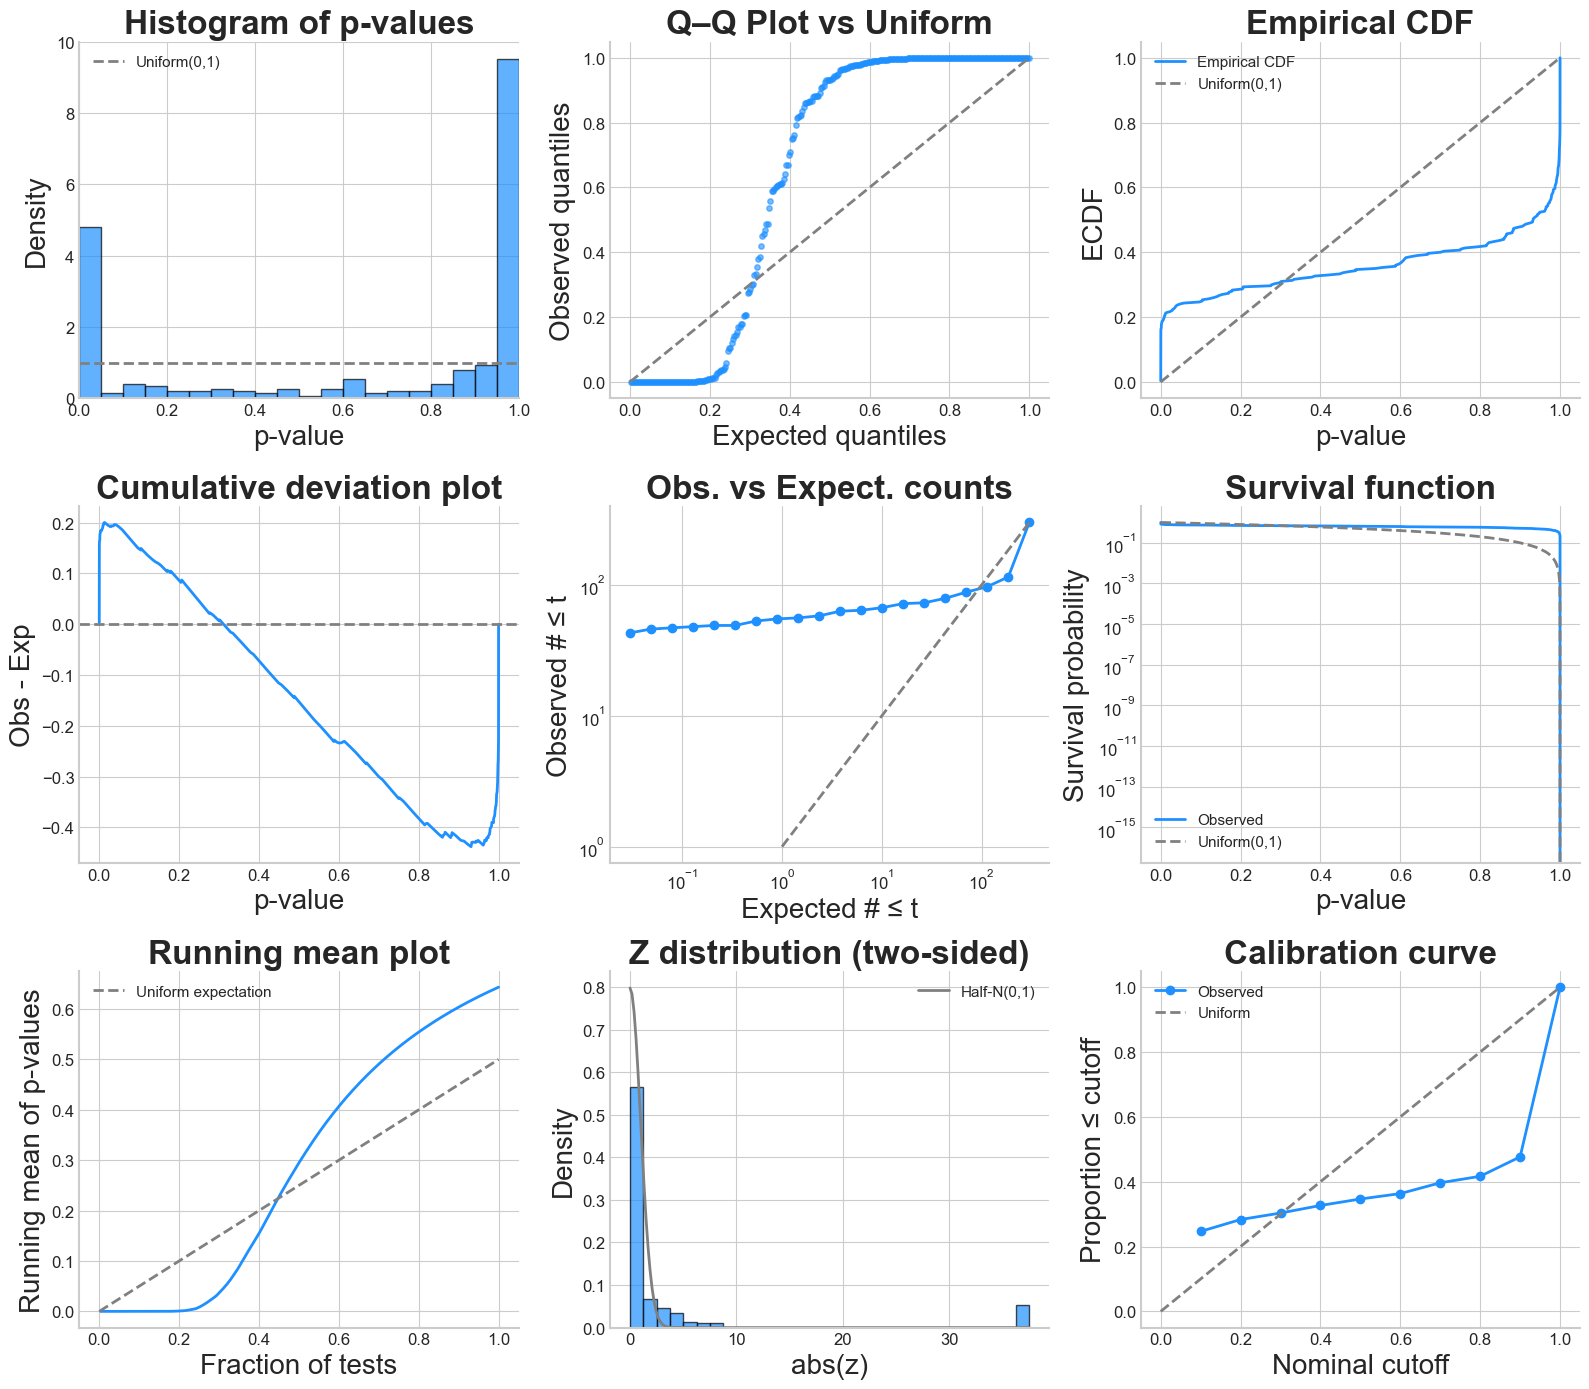

<Figure size 640x480 with 0 Axes>

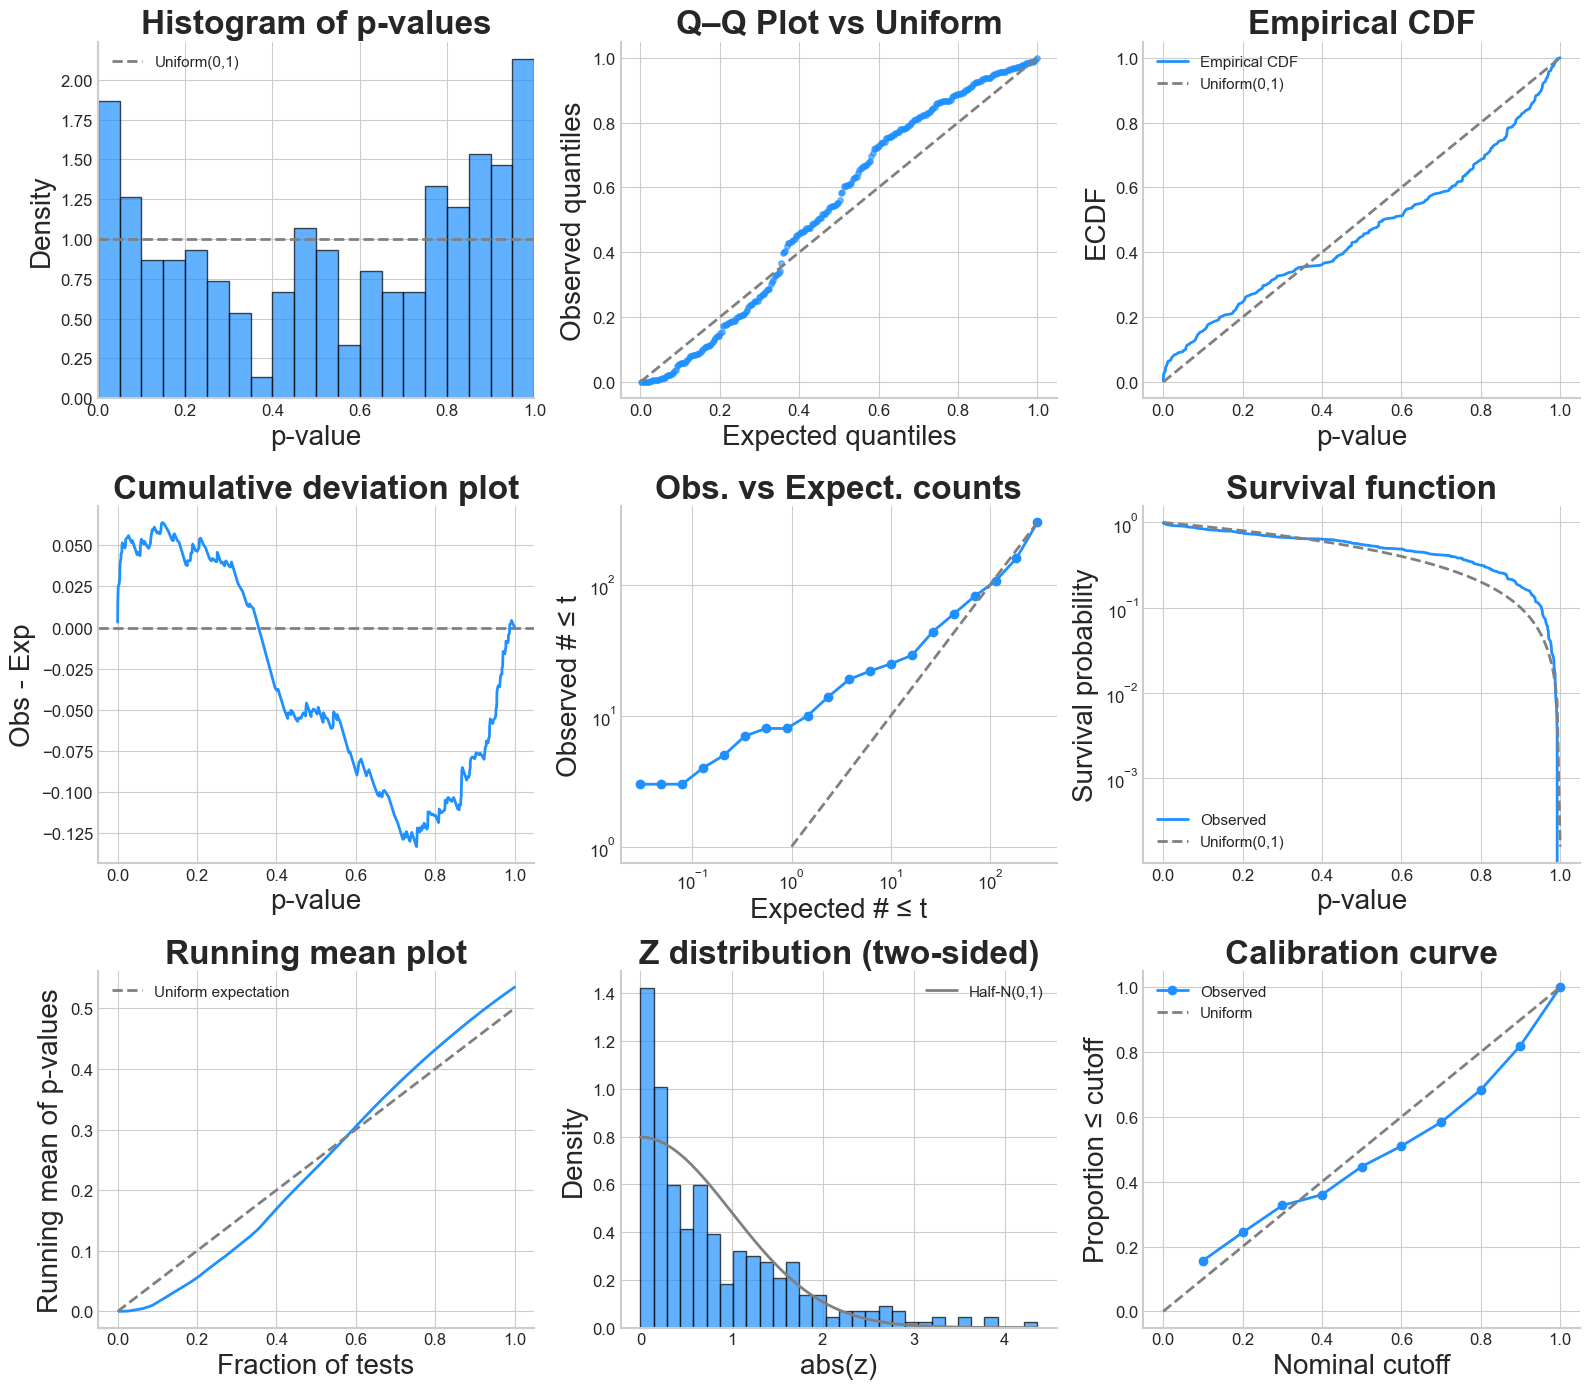

<Figure size 640x480 with 0 Axes>

In [5]:
for name, pvals in pvals_dict.items():
    fig = plot_pvalue_diagnostics_grid(pvals)
    if fig is not None:
        fig.suptitle(f"P-value Calibration Grid - {name} Null", fontsize=16)
        plt.tight_layout()
        plt.show()


## 4. Power Analysis Under Alternatives

We evaluate the statistical power of the test under alternatives. Power is the probability of correctly rejecting the null hypothesis when the alternative is true (measured here as the proportion of p-values $< 0.05$).

We consider two alternative covariance structures where group 2 breaks proportionality:
1. **Spiked alternative**: $\Sigma_1 = I_p$ and $\Sigma_2 = 2.0 \cdot \text{generate_spiked_covariance}(p, \theta)$. When $\theta = 1.0$, the matrices are proportional (so power should be $\approx 0.05$).
2. **Toeplitz alternative**: $\Sigma_1 = I_p$ and $\Sigma_2 = 2.0 \cdot \text{generate_toeplitz_cov}(p, \rho)$. When $\rho = 0.0$, the matrices are proportional.


In [6]:
M_alt = 100
n, p = 100, 15
Sigma1 = np.eye(p)

# Spiked alternative
spike_values = np.array([1.0, 1.5, 2.0, 3.0, 4.5, 6.0])
pvals_spiked = []

for spike in spike_values:
    col_pvals = []
    if spike > 1.0:
        Sigma2 = 2.0 * generate_spiked_covariance(p, spike_eigenvalue=spike, num_spikes=1, rng=rng)
    else:
        Sigma2 = 2.0 * np.eye(p)
    for _ in range(M_alt):
        X = generate_heavy_tailed_samples(Sigma1, n, dist_type="normal", rng=rng)
        Y = generate_heavy_tailed_samples(Sigma2, n, dist_type="normal", rng=rng)
        res = proportionality_test_LZ(X, Y)
        col_pvals.append(res["p_value"])
    pvals_spiked.append(col_pvals)

pvals_spiked = np.array(pvals_spiked).T


In [7]:
# Toeplitz alternative
rho_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
pvals_toeplitz = []

for rho in rho_values:
    col_pvals = []
    if rho > 0.0:
        Sigma2 = 2.0 * generate_toeplitz_cov(p, rho)
    else:
        Sigma2 = 2.0 * np.eye(p)
    for _ in range(M_alt):
        X = generate_heavy_tailed_samples(Sigma1, n, dist_type="normal", rng=rng)
        Y = generate_heavy_tailed_samples(Sigma2, n, dist_type="normal", rng=rng)
        res = proportionality_test_LZ(X, Y)
        col_pvals.append(res["p_value"])
    pvals_toeplitz.append(col_pvals)

pvals_toeplitz = np.array(pvals_toeplitz).T


Plotting power curve for Spiked Alternative:


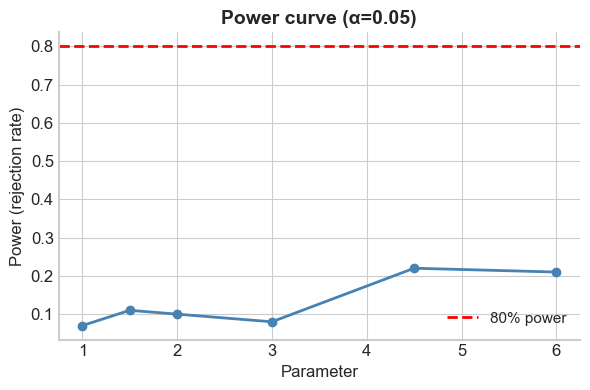

In [8]:
# Plotting spiked power curve
print("Plotting power curve for Spiked Alternative:")
plot_power_curve(pvals_spiked, spike_values, alpha=0.05)


Plotting power curve for Toeplitz Alternative:


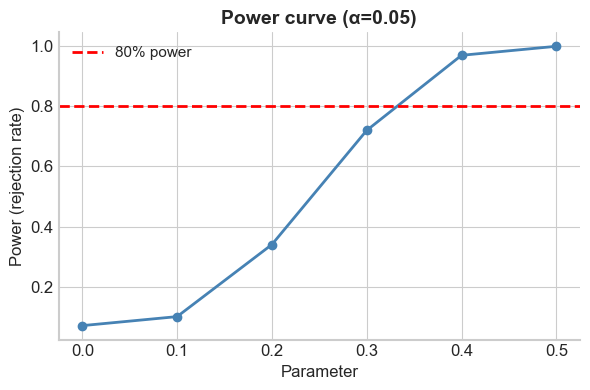

In [9]:
# Plotting Toeplitz power curve
print("Plotting power curve for Toeplitz Alternative:")
plot_power_curve(pvals_toeplitz, rho_values, alpha=0.05)


### Power Heatmap Over Sample Sizes ($n$) and Dimensions ($p$)
We now analyze how power varies over a grid of sample sizes and dimensions under a fixed spiked alternative.


Running grid simulations...
Plotting power heatmap over sample sizes (n) and dimensions (p):


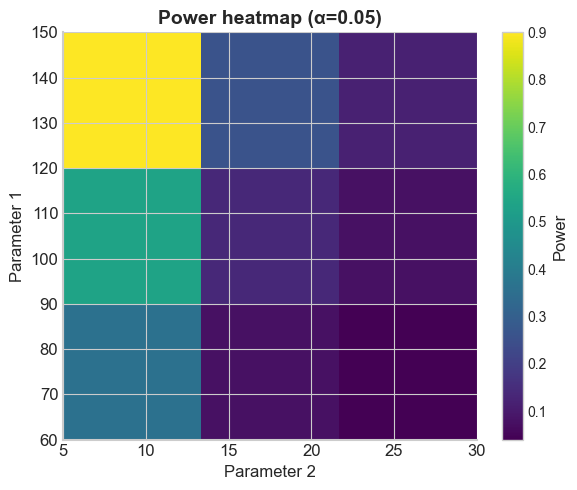

In [10]:
sample_sizes = np.array([60, 100, 150])
dimensions = np.array([5, 15, 30])
pvals_grid = []
spike_val = 3.5

print("Running grid simulations...")
for n_val in sample_sizes:
    row_pvals = []
    for p_val in dimensions:
        cell_pvals = []
        Sigma1 = np.eye(p_val)
        Sigma2 = 2.0 * generate_spiked_covariance(p_val, spike_eigenvalue=spike_val, num_spikes=1, rng=rng)
        for _ in range(50):
            X = generate_heavy_tailed_samples(Sigma1, n_val, dist_type="normal", rng=rng)
            Y = generate_heavy_tailed_samples(Sigma2, n_val, dist_type="normal", rng=rng)
            res = proportionality_test_LZ(X, Y)
            cell_pvals.append(res["p_value"])
        row_pvals.append(cell_pvals)
    pvals_grid.append(row_pvals)

pvals_grid = np.transpose(np.array(pvals_grid), (2, 0, 1))

print("Plotting power heatmap over sample sizes (n) and dimensions (p):")
plot_power_heatmap(pvals_grid, sample_sizes, dimensions, alpha=0.05)
